In [1]:
import kagglehub
blastchar_telco_customer_churn_path = kagglehub.dataset_download('blastchar/telco-customer-churn')

print('Data source import complete.')


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Data source import complete.


In [2]:
# 1. to handle the data
import pandas as pd
import numpy as np
from scipy import stats

# to visualize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
# pipeline
from sklearn.pipeline import Pipeline
# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error,mean_squared_error,r2_score

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:

df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

pd.set_option('display.max_columns', None)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df.dropna(inplace=True)

df.drop('customerID', axis=1, inplace=True)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


In [8]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


<Axes: >

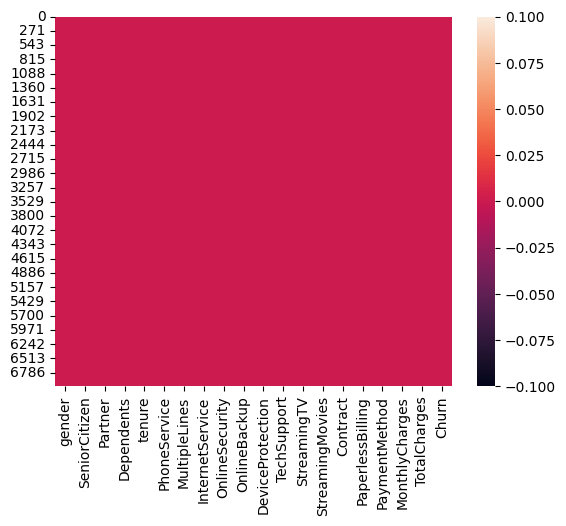

In [9]:
sns.heatmap(df.isnull())

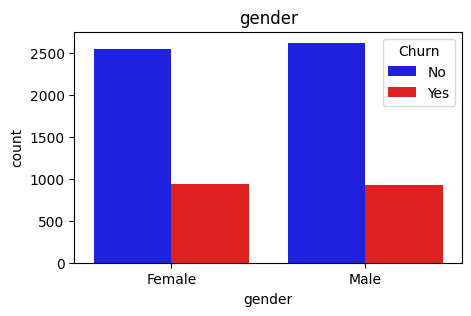

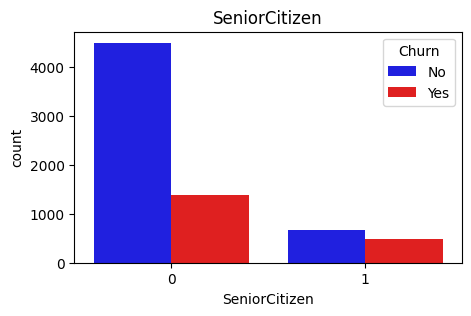

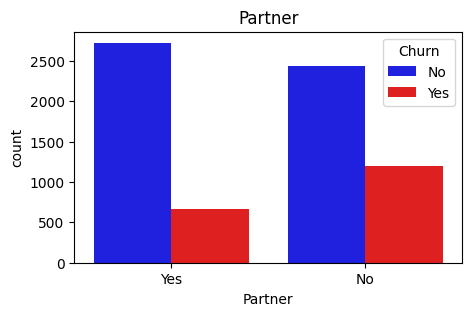

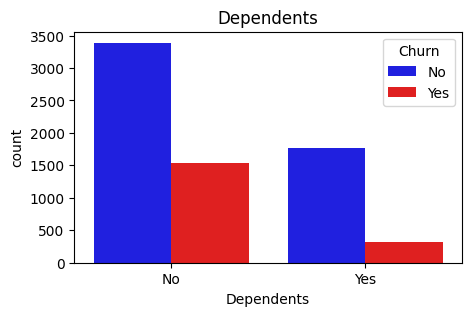

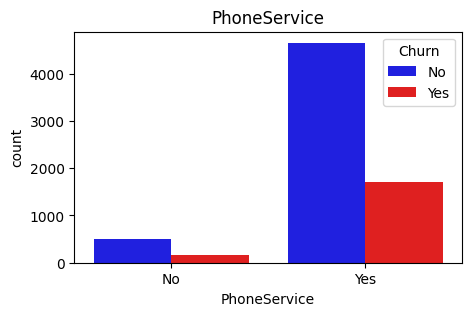

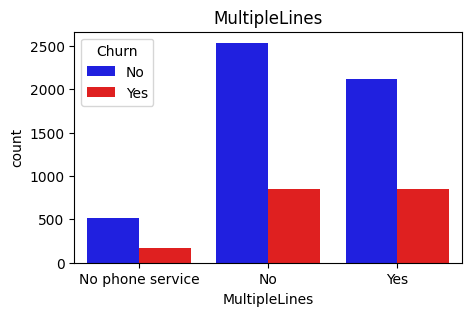

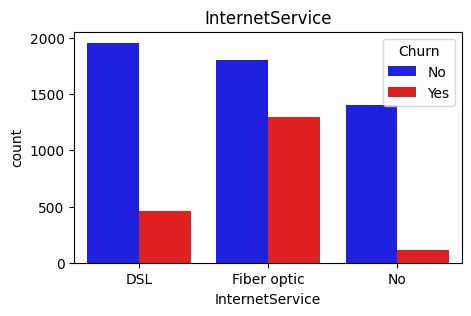

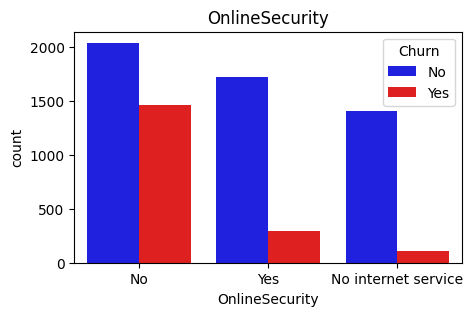

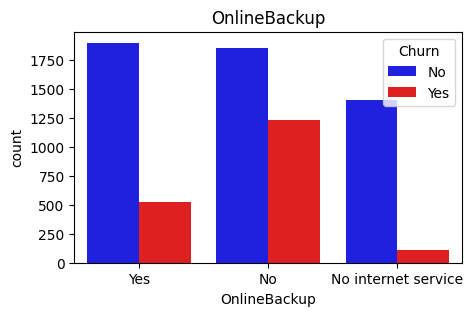

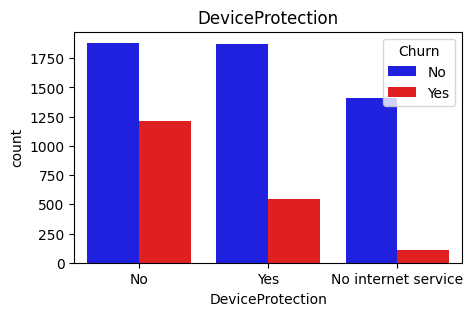

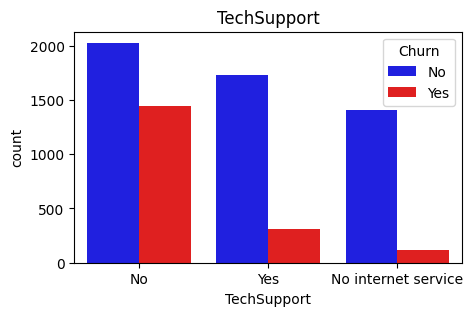

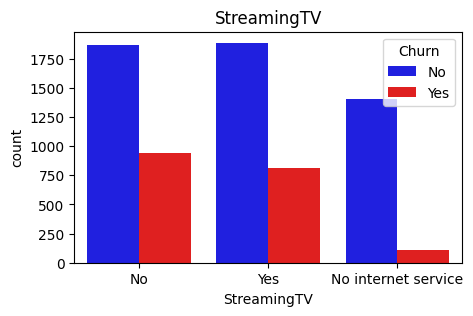

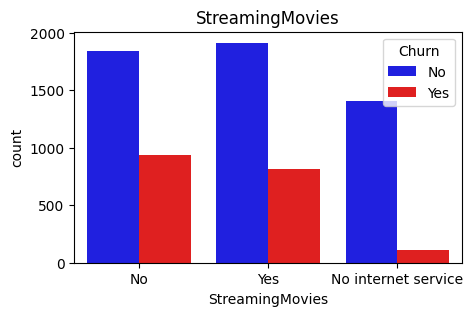

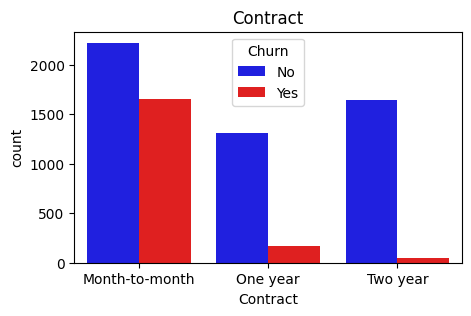

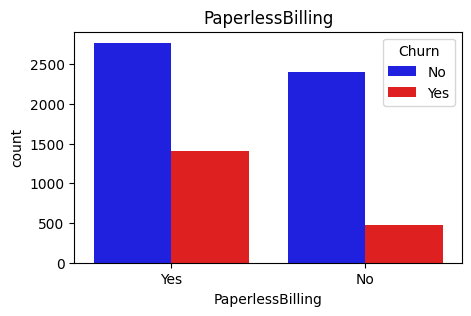

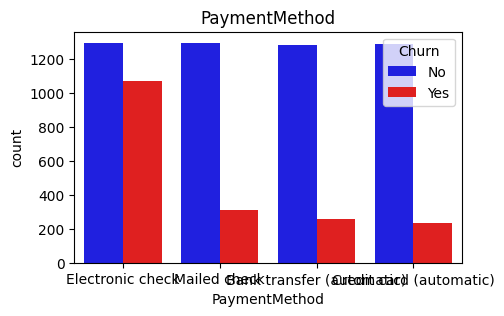

In [10]:
# Define colors for Yes and No
colors = {'Yes': 'red', 'No': 'blue'}

# Add missing keys for 0 and 1 in the palette
palette = {0: 'blue', 1: 'red'}

for i, predictor in enumerate(df.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges', 'tenure'])):
    plt.figure(i, figsize=(5, 3))
    sns.countplot(data=df, x=predictor, hue='Churn', palette=colors)
    plt.title(predictor)
    plt.show()


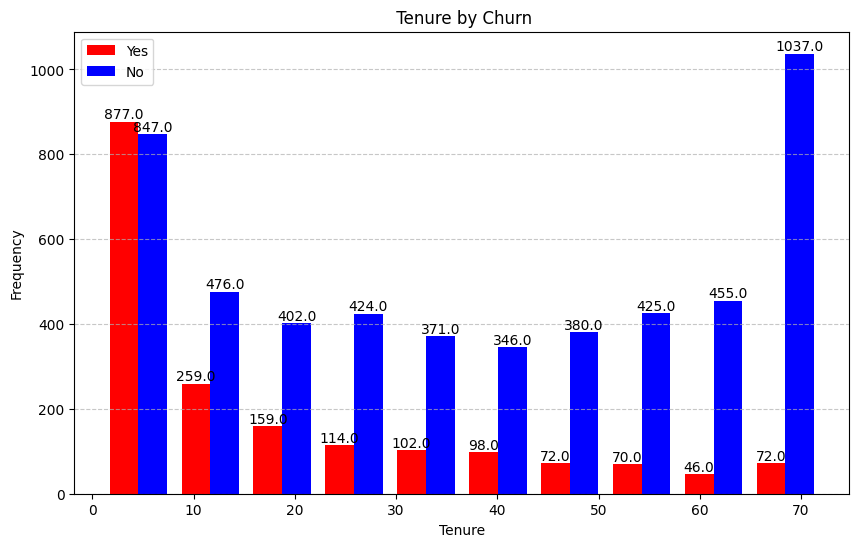

In [11]:
# make plot for tenure
churned = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['tenure'], not_churned['tenure']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])
plt.title(' Tenure by Churn')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')


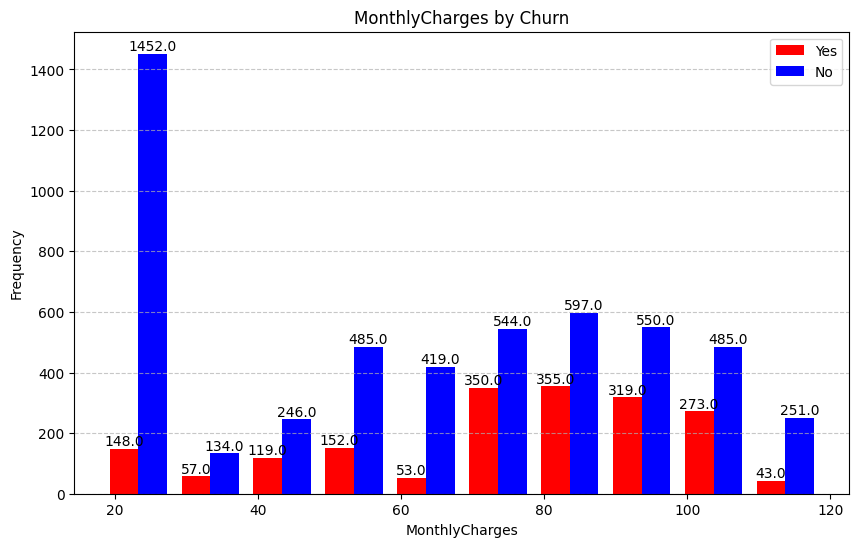

In [12]:
# make plot for MonthlyCharges
churned = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['MonthlyCharges'], not_churned['MonthlyCharges']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])
plt.title('MonthlyCharges by Churn')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')


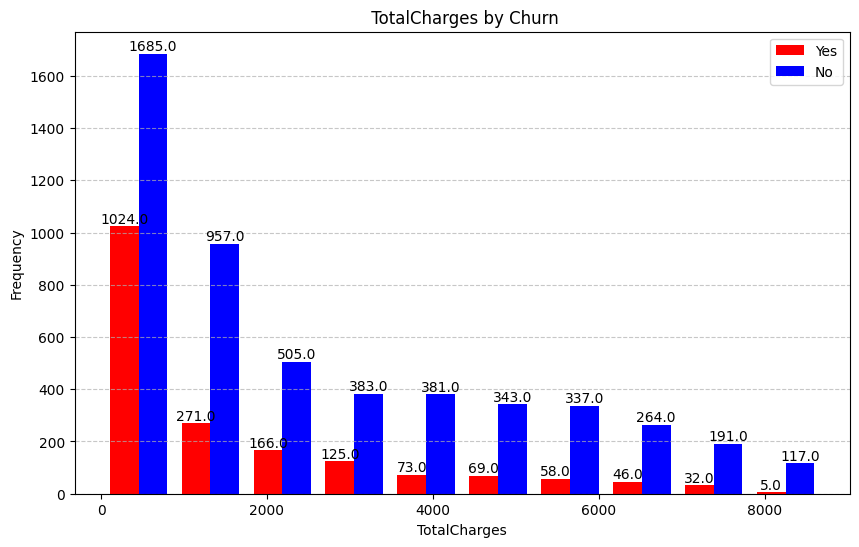

In [13]:
# make plot for tenure
churned = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['TotalCharges'], not_churned['TotalCharges']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])
plt.title(' TotalCharges by Churn')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')


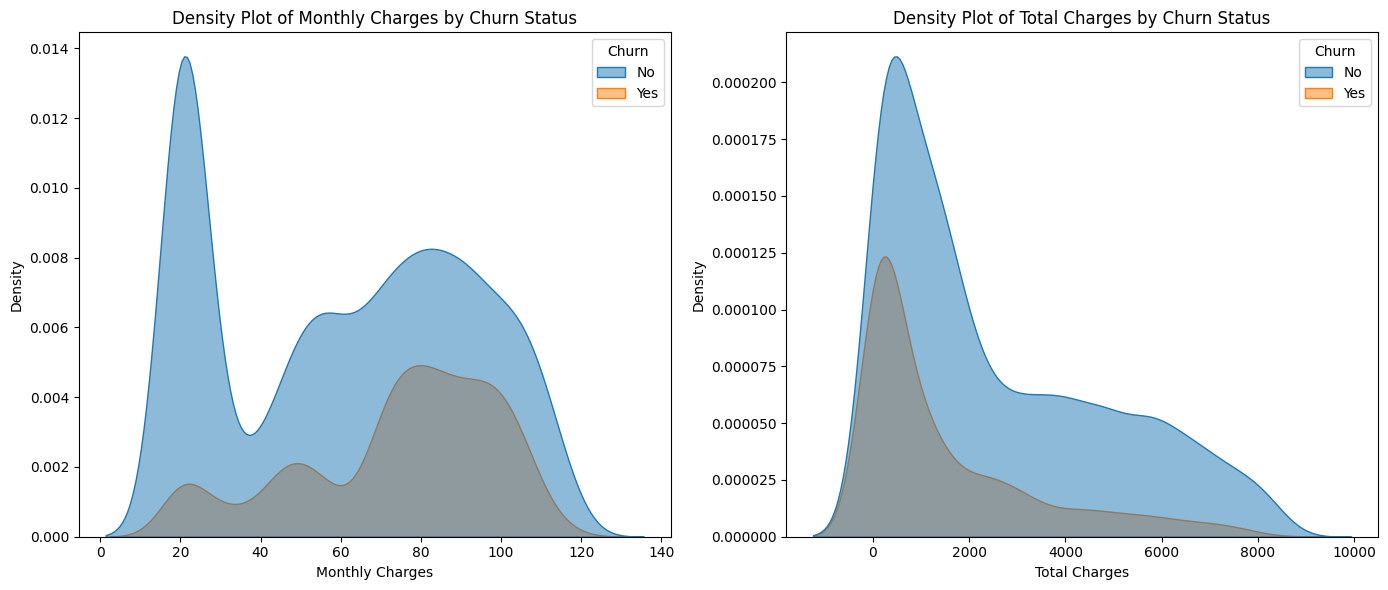

In [14]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Monthly Charges
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Density Plot of Monthly Charges by Churn Status')
axes[0].set_xlabel('Monthly Charges')
axes[0].set_ylabel('Density')

# Plot for Total Charges
sns.kdeplot(data=df, x="TotalCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Density Plot of Total Charges by Churn Status')
axes[1].set_xlabel('Total Charges')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()


In [15]:
for col in df.columns:
    if df[col].dtype != 'int64' and df[col].dtype != 'float64':
        print(f'{col} : {df[col].unique()}')

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


In [16]:
df['gender']=df['gender'].map({'Female':1, 'Male':2})

In [17]:
df['Partner']=df['Partner'].map({'Yes':1, 'No':2})

In [18]:
df['Dependents']=df['Dependents'].map({'No':1, 'Yes':2})

In [19]:
df['PhoneService']=df['PhoneService'].map({'No':1, 'Yes':2})

In [20]:
df['MultipleLines']=df['MultipleLines'].map({'No phone service':1, 'No':2, 'Yes':3})

In [21]:
df['InternetService']=df['InternetService'].map({'DSL':1, 'No':2, 'Fiber optic':3})

In [22]:
df['OnlineSecurity']=df['OnlineSecurity'].map({'No internet service':1, 'No':2, 'Yes':3})

In [23]:
df['OnlineBackup']=df['OnlineBackup'].map({'No internet service':1, 'No':2, 'Yes':3})

In [24]:
df['DeviceProtection']=df['DeviceProtection'].map({'No internet service':1, 'No':2, 'Yes':3})

In [25]:
df['TechSupport']=df['TechSupport'].map({'No internet service':1, 'No':2, 'Yes':3})

In [26]:
df['StreamingTV']=df['StreamingTV'].map({'No internet service':1, 'No':2, 'Yes':3})

In [27]:
df['StreamingMovies']=df['StreamingMovies'].map({'No internet service':1, 'No':2, 'Yes':3})

In [28]:
df['Contract']=df['Contract'].map({'Month-to-month':1, 'One year':2, 'Two year':3})

In [29]:
df['PaperlessBilling']=df['PaperlessBilling'].map({'Yes':1, 'No':2})

In [30]:
df['Churn']=df['Churn'].map({'Yes':1, 'No':2})

In [31]:
df['PaymentMethod']=df['PaymentMethod'].map({'Electronic check':1, 'Mailed check':2, 'Bank transfer (automatic)':3, 'Credit card (automatic)':4})

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

In [33]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,1,1,1,1,1,2,3,2,2,2,2,1,1,1,29.85,29.85,2
1,2,0,2,1,34,2,2,1,3,2,3,2,2,2,2,2,2,56.95,1889.50,2
2,2,0,2,1,2,2,2,1,3,3,2,2,2,2,1,1,2,53.85,108.15,1
3,2,0,2,1,45,1,1,1,3,2,3,3,2,2,2,2,3,42.30,1840.75,2
4,1,0,2,1,2,2,2,3,2,2,2,2,2,2,1,1,1,70.70,151.65,1


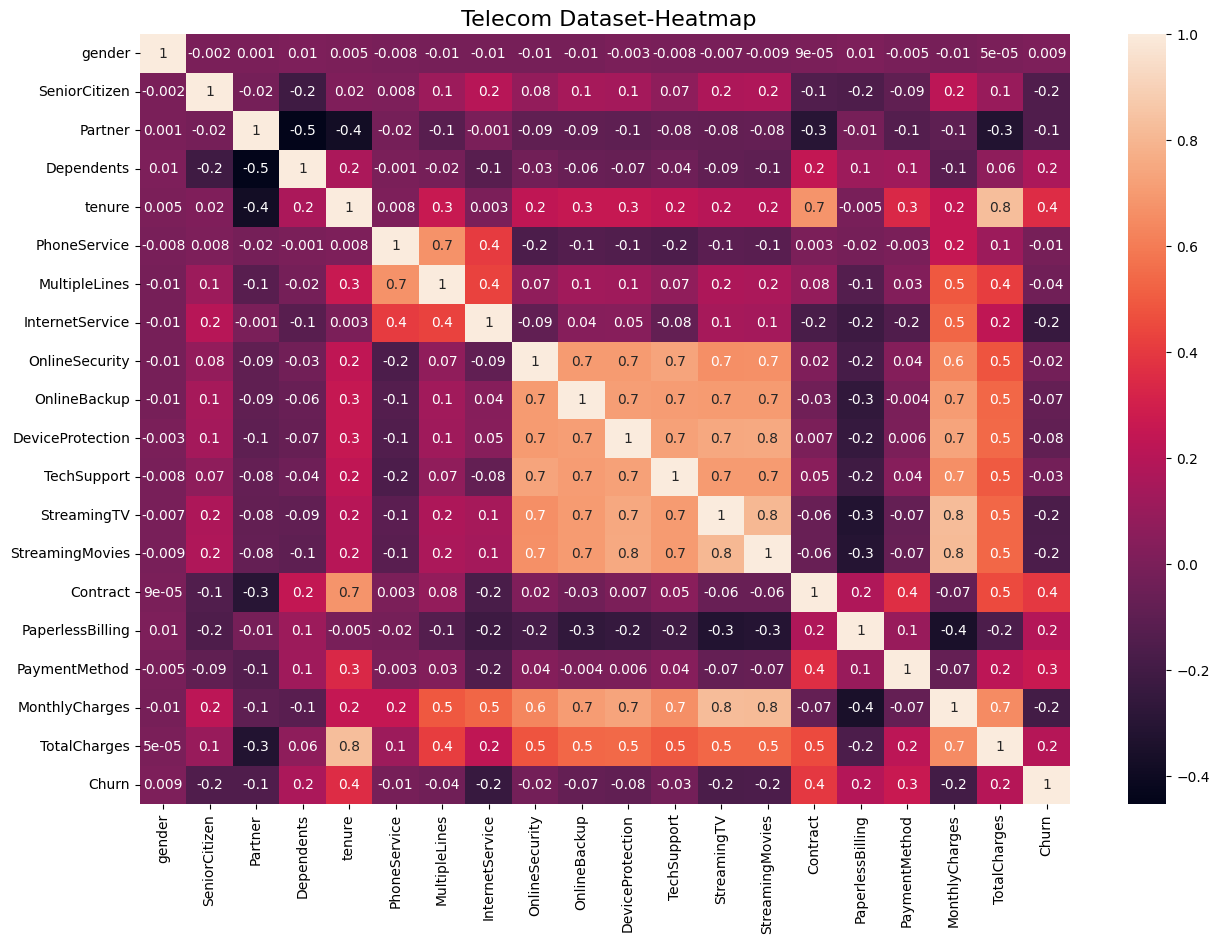

In [34]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(df.corr(),annot=True,fmt='.1g',)
plt.title(" Telecom Dataset-Heatmap", fontsize=16)
plt.savefig("telecom heatmap",dpi=700)
plt.show()

In [35]:
df.corr()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001819,0.001379,0.010349,0.005285,-0.007515,-0.010284,-0.010404,-0.013233,-0.011081,-0.003168,-0.008215,-0.007163,-0.009072,0.000095,0.011902,-0.004928,-0.013779,0.000048,0.008545
SeniorCitizen,-0.001819,1.000000,-0.016957,-0.210550,0.015683,0.008392,0.113769,0.202225,0.081766,0.144762,0.140226,0.067318,0.167123,0.176125,-0.141820,-0.156258,-0.093712,0.219874,0.102411,-0.150541
Partner,0.001379,-0.016957,1.000000,-0.452269,-0.381912,-0.018397,-0.118037,-0.001259,-0.092034,-0.091536,-0.099077,-0.077252,-0.080205,-0.076076,-0.294094,-0.013957,-0.133280,-0.097825,-0.319072,-0.149982
Dependents,0.010349,-0.210550,-0.452269,1.000000,0.163386,-0.001078,-0.019178,-0.120407,-0.028964,-0.061970,-0.068296,-0.040057,-0.085909,-0.099795,0.240556,0.110131,0.124002,-0.112343,0.064653,0.163128
tenure,0.005285,0.015683,-0.381912,0.163386,1.000000,0.007877,0.259112,0.002674,0.232295,0.253575,0.253834,0.230429,0.200646,0.203834,0.676734,-0.004823,0.340939,0.246862,0.825880,0.354049
PhoneService,-0.007515,0.008392,-0.018397,-0.001078,0.007877,1.000000,0.674824,0.407735,-0.158997,-0.129432,-0.141055,-0.160950,-0.107242,-0.114798,0.003019,-0.016696,-0.003106,0.248033,0.113008,-0.011691
MultipleLines,-0.010284,0.113769,-0.118037,-0.019178,0.259112,0.674824,1.000000,0.429498,0.069959,0.130978,0.125447,0.069706,0.166256,0.163218,0.084037,-0.133538,0.026248,0.491412,0.412495,-0.036148
InternetService,-0.010404,0.202225,-0.001259,-0.120407,0.002674,0.407735,0.429498,1.000000,-0.088149,0.037993,0.045837,-0.081811,0.145811,0.139360,-0.172134,-0.218362,-0.150643,0.531119,0.231665,-0.240423
OnlineSecurity,-0.013233,0.081766,-0.092034,-0.028964,0.232295,-0.158997,0.069959,-0.088149,1.000000,0.704598,0.701112,0.734696,0.661541,0.666682,0.016495,-0.184449,0.035563,0.635260,0.483157,-0.023014
OnlineBackup,-0.011081,0.144762,-0.091536,-0.061970,0.253575,-0.129432,0.130978,0.037993,0.704598,1.000000,0.710790,0.708659,0.702605,0.699828,-0.034745,-0.260691,-0.003786,0.710175,0.537726,-0.073934


In [36]:
df['gender']=(df['gender']-df['gender'].min())/(df['gender'].max()-df['gender'].min())

In [37]:
df['SeniorCitizen']=(df['SeniorCitizen']-df['SeniorCitizen'].min())/(df['SeniorCitizen'].max()-df['SeniorCitizen'].min())

In [38]:
df['Partner']=(df['Partner']-df['Partner'].min())/(df['Partner'].max()-df['Partner'].min())

In [39]:
df['Dependents']=(df['Dependents']-df['Dependents'].min())/(df['Dependents'].max()-df['Dependents'].min())

In [40]:
df['tenure']=(df['tenure']-df['tenure'].min())/(df['tenure'].max()-df['tenure'].min())

In [41]:
df['PhoneService']=(df['PhoneService']-df['PhoneService'].min())/(df['PhoneService'].max()-df['PhoneService'].min())

In [42]:
df['MultipleLines']=(df['MultipleLines']-df['MultipleLines'].min())/(df['MultipleLines'].max()-df['MultipleLines'].min())

In [43]:
df['InternetService']=(df['InternetService']-df['InternetService'].min())/(df['InternetService'].max()-df['InternetService'].min())

In [44]:
df['OnlineSecurity']=(df['OnlineSecurity']-df['OnlineSecurity'].min())/(df['OnlineSecurity'].max()-df['OnlineSecurity'].min())

In [45]:
df['OnlineBackup']=(df['OnlineBackup']-df['OnlineBackup'].min())/(df['OnlineBackup'].max()-df['OnlineBackup'].min())

In [46]:
df['DeviceProtection']=(df['DeviceProtection']-df['DeviceProtection'].min())/(df['DeviceProtection'].max()-df['DeviceProtection'].min())

In [47]:
df['TechSupport']=(df['TechSupport']-df['TechSupport'].min())/(df['TechSupport'].max()-df['TechSupport'].min())

In [48]:
df['StreamingTV']=(df['StreamingTV']-df['StreamingTV'].min())/(df['StreamingTV'].max()-df['StreamingTV'].min())

In [49]:
df['StreamingMovies']=(df['StreamingMovies']-df['StreamingMovies'].min())/(df['StreamingMovies'].max()-df['StreamingMovies'].min())

In [50]:
df['Contract']=(df['Contract']-df['Contract'].min())/(df['Contract'].max()-df['Contract'].min())

In [51]:
df['PaperlessBilling']=(df['PaperlessBilling']-df['PaperlessBilling'].min())/(df['PaperlessBilling'].max()-df['PaperlessBilling'].min())

In [52]:
df['PaymentMethod']=(df['PaymentMethod']-df['PaymentMethod'].min())/(df['PaymentMethod'].max()-df['PaymentMethod'].min())

In [53]:
df['MonthlyCharges']=(df['MonthlyCharges']-df['MonthlyCharges'].min())/(df['MonthlyCharges'].max()-df['MonthlyCharges'].min())

In [54]:
df['TotalCharges']=(df['TotalCharges']-df['TotalCharges'].min())/(df['TotalCharges'].max()-df['TotalCharges'].min())

In [55]:
df['Churn']=(df['Churn']-df['Churn'].min())/(df['Churn'].max()-df['Churn'].min())

In [56]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.5,1.0,0.5,0.5,0.5,0.5,0.0,0.0,0.000000,0.115423,0.001275,1.0
1,1.0,0.0,1.0,0.0,0.464789,1.0,0.5,0.0,1.0,0.5,1.0,0.5,0.5,0.5,0.5,1.0,0.333333,0.385075,0.215867,1.0
2,1.0,0.0,1.0,0.0,0.014085,1.0,0.5,0.0,1.0,1.0,0.5,0.5,0.5,0.5,0.0,0.0,0.333333,0.354229,0.010310,0.0
3,1.0,0.0,1.0,0.0,0.619718,0.0,0.0,0.0,1.0,0.5,1.0,1.0,0.5,0.5,0.5,1.0,0.666667,0.239303,0.210241,1.0
4,0.0,0.0,1.0,0.0,0.014085,1.0,0.5,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.0,0.0,0.000000,0.521891,0.015330,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,0.0,0.0,1.0,0.323944,1.0,1.0,0.0,1.0,0.5,1.0,1.0,1.0,1.0,0.5,0.0,0.333333,0.662189,0.227521,1.0
7039,0.0,0.0,0.0,1.0,1.000000,1.0,1.0,1.0,0.5,1.0,1.0,0.5,1.0,1.0,0.5,0.0,1.000000,0.845274,0.847461,1.0
7040,0.0,0.0,0.0,1.0,0.140845,0.0,0.0,0.0,1.0,0.5,0.5,0.5,0.5,0.5,0.0,0.0,0.000000,0.112935,0.037809,1.0
7041,1.0,1.0,0.0,0.0,0.042254,1.0,1.0,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.0,0.0,0.333333,0.558706,0.033210,0.0


In [57]:
from sklearn.model_selection import train_test_split

In [58]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [60]:
x = df.drop('Churn', axis=1)
y = df['Churn']

In [61]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [62]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

In [63]:
rf_classifier.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [64]:
y_pred = rf_classifier.predict(x_test)

In [65]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

In [66]:
print(f'Model Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

Model Accuracy: 0.79
Precision: 0.78
Recall: 0.79
F1 Score: 0.78


In [67]:
# full corrected script (scaler removed)
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# --- Assume x_train, x_test, y_train, y_test are already defined ---

# Initialize an empty list to store model scores
model_scores = []

# Create a list of models to evaluate (only selected models, no scaler)
models = [
    ('Random Forest', RandomForestClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__max_depth': [None, 10, 20]}),

    ('K-Nearest Neighbors', KNeighborsClassifier(),
        {'model__n_neighbors': [3, 5, 7],
         'model__weights': ['uniform', 'distance']}),

    ('AdaBoost', AdaBoostClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),

    ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),

    ('Naive Bayes', GaussianNB(), {})  # No hyperparameters
]

best_model = None
best_accuracy = 0.0

# Iterate over the models and evaluate their performance
for name, model, param_grid in models:

    # Create a pipeline for each model WITHOUT a scaler
    pipeline = Pipeline([
        ('model', model)
    ])

    # Hyperparameter tuning using GridSearchCV (only if param_grid supplied)
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=2, n_jobs=-1)
        grid_search.fit(x_train, y_train)
        pipeline = grid_search.best_estimator_

    # Fit the pipeline on the training data
    pipeline.fit(x_train, y_train)

    # Make predictions on the test data
    y_pred = pipeline.predict(x_test)

    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)

    # Append model name and accuracy to the list
    model_scores.append({'Model': name, 'Accuracy': accuracy})

    # Print the performance metrics
    print(f"Model: {name}")
    print(f"Test Accuracy: {accuracy * 100:.2f}%")
    print()

    # Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Convert results to DataFrame and show summary
scores_df = pd.DataFrame(model_scores).sort_values(by='Accuracy', ascending=False)
print("All model scores (sorted):")
print(scores_df.to_string(index=False))

# Retrieve the overall best model
print("\nBest Model:")
print(f"Test Accuracy: {best_accuracy * 100:.2f}%")
print("Best Model Pipeline:", best_model)


Model: Random Forest
Test Accuracy: 78.75%

Model: K-Nearest Neighbors
Test Accuracy: 75.62%

Model: AdaBoost
Test Accuracy: 78.39%

Model: XGBoost
Test Accuracy: 78.96%

Model: Naive Bayes
Test Accuracy: 72.78%

All model scores (sorted):
              Model  Accuracy
            XGBoost  0.789623
      Random Forest  0.787491
           AdaBoost  0.783937
K-Nearest Neighbors  0.756219
        Naive Bayes  0.727790

Best Model:
Test Accuracy: 78.96%
Best Model Pipeline: Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
  

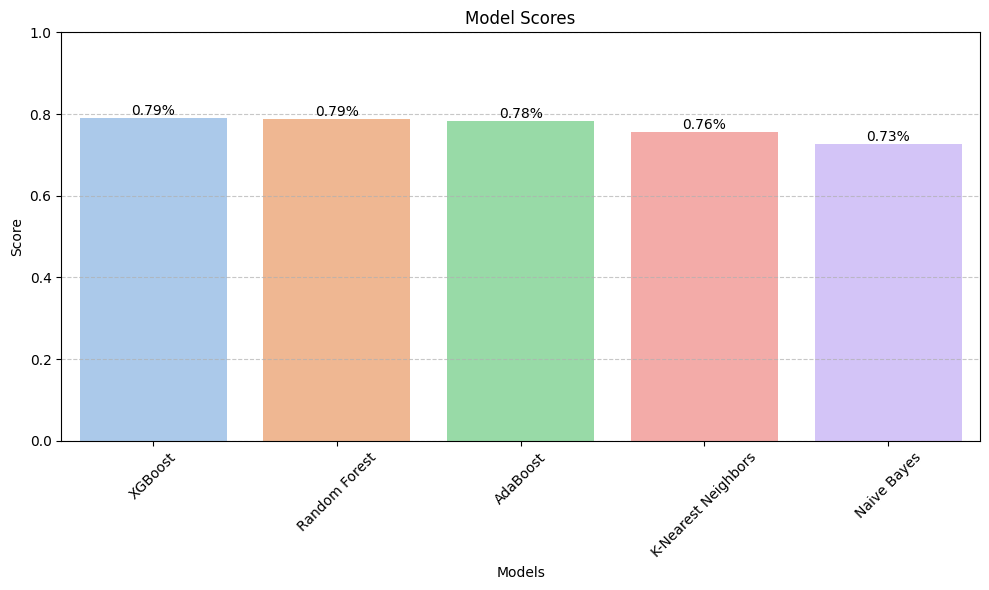

In [68]:
# Define a color palette for the bars
colors = sns.color_palette('pastel', n_colors=len(scores_df))

# Create a bar plot of models and their scores
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=scores_df, palette=colors)

# Add text on each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Model Scores')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [69]:
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
import pandas as pd
from scipy.stats import uniform, randint

# UpSampling
sm = SMOTEENN()
X_res, y_res = sm.fit_resample(x, y)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_res, y_res, test_size=0.2)

# Initialize an empty list to store model scores
model_scores = []

# Create a list of models to evaluate (ONLY the ones you kept)
models = [
    ('Random Forest', RandomForestClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__max_depth': [None, 10, 20]}),

    ('K-Nearest Neighbors', KNeighborsClassifier(),
        {'model__n_neighbors': [3, 5, 7],
         'model__weights': ['uniform', 'distance']}),

    ('Ada Boost', AdaBoostClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),

    ('XG Boost', XGBClassifier(random_state=42),
        {'model__max_depth': randint(3, 6),
         'model__learning_rate': uniform(0.01, 0.2),
         'model__n_estimators': randint(100, 300),
         'model__subsample': uniform(0.8, 0.2)}),

    ('Naive Bayes', GaussianNB(), {})  # No hyperparameters
]

best_model = None
best_accuracy = 0.0

# Iterate over all models
for name, model, param_grid in models:

    # Pipeline WITHOUT MinMaxScaler
    pipeline = Pipeline([
        ('model', model)
    ])

    # XGBoost uses RandomizedSearchCV
    if name == 'XG Boost':
        random_search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            n_iter=50,
            cv=3,
            verbose=0,
            random_state=42,
            n_jobs=-1
        )
        random_search.fit(Xr_train, yr_train)
        pipeline = random_search.best_estimator_

    # All other models use GridSearchCV
    elif param_grid:
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=2,
            verbose=0,
            n_jobs=-1
        )
        grid_search.fit(Xr_train, yr_train)
        pipeline = grid_search.best_estimator_

    # Fit the model
    pipeline.fit(Xr_train, yr_train)

    # Predict
    y_pred = pipeline.predict(Xr_test)

    # Accuracy
    accuracy = accuracy_score(yr_test, y_pred)

    # Store
    model_scores.append({'Model': name, 'Accuracy': accuracy})

    print("\nModel:", name)
    print("Test Accuracy:", round(accuracy * 100, 2), "%")

    # Track best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Summary
scores_df = pd.DataFrame(model_scores)
print("\nAll model scores:")
print(scores_df)

print("\nBest Model:")
print("Accuracy:", round(best_accuracy * 100, 2), "%")
print(best_model)



Model: Random Forest
Test Accuracy: 96.35 %

Model: K-Nearest Neighbors
Test Accuracy: 97.38 %

Model: Ada Boost
Test Accuracy: 92.85 %

Model: XG Boost
Test Accuracy: 96.03 %

Model: Naive Bayes
Test Accuracy: 89.67 %

All model scores:
                 Model  Accuracy
0        Random Forest  0.963463
1  K-Nearest Neighbors  0.973789
2            Ada Boost  0.928515
3             XG Boost  0.960286
4          Naive Bayes  0.896743

Best Model:
Accuracy: 97.38 %
Pipeline(steps=[('model',
                 KNeighborsClassifier(n_neighbors=3, weights='distance'))])


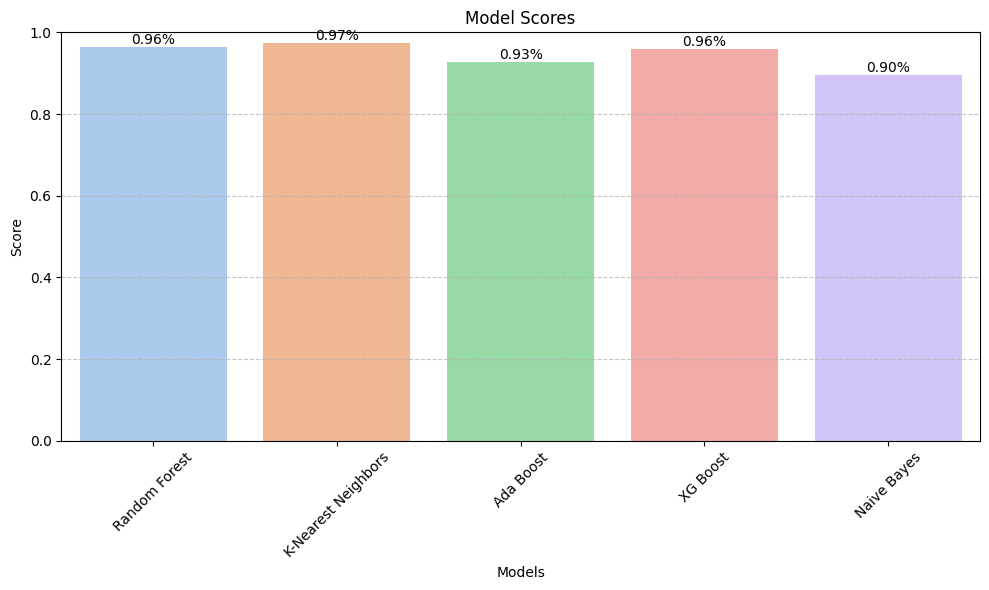

In [70]:
# Define a color palette for the bars
colors = sns.color_palette('pastel', n_colors=len(scores_df))

# Create a bar plot of models and their scores
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=scores_df, palette=colors)

# Add text on each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Model Scores')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


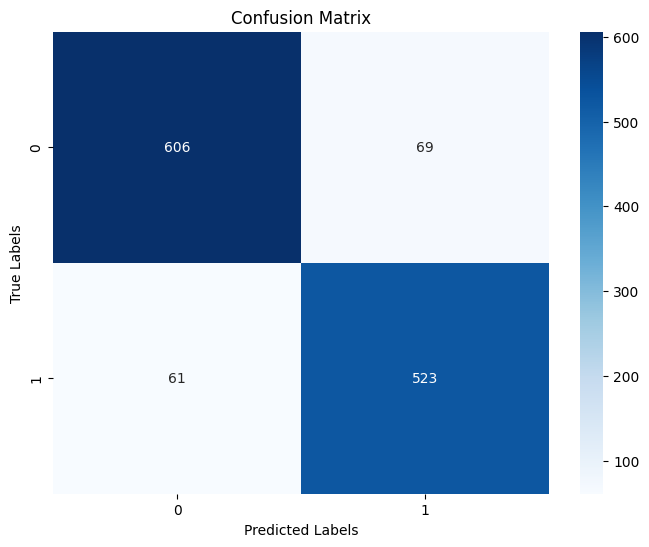

In [71]:
# Compute confusion matrix
conf_matrix = confusion_matrix(yr_test, y_pred)

# Display confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [72]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))

print("model.pkl saved successfully!")

model.pkl saved successfully!


In [73]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>